# 1. IMAGE SEGMENTATION

## 1.1 THRESHOLD-BASED SEGMENTATION

El objetivo de esta sección es detectar defectos en una radiografía de una soldadura. Sabemos que los defectos dejan pasar más los rayos X, por lo que se ven como las regiones más brillantes del interior.
Para lograr aislar estos defectos, aplicaremos una técnica llamada Umbralización (Thresholding).

La regla matemática básica es:

- Si el valor del píxel $f(x,y) > T$ (siendo $T$ nuestro umbral), el nuevo píxel será Blanco (1 o 255).
- Si el valor del píxel $f(x,y) \le T$, el nuevo píxel será Negro (0).

¿Cómo elegimos $T$?

Umbral de Otsu: El laboratorio nos pide usar primero la función threshold_otsu. Este es un algoritmo que analiza el histograma de la imagen (la distribución de grises) y calcula automáticamente el valor $T$ óptimo que separa la imagen en dos clases equilibradas (fondo y objeto), minimizando la varianza estadística dentro de cada clase.

Umbral Manual: Otsu funciona muy bien cuando hay dos montañas claras (bimodal) en el histograma. Sin embargo, en una radiografía, los defectos brillantes son muy pequeños en área comparados con el resto de la soldadura. Esto engaña a Otsu. Por eso, el laboratorio nos pide luego ver el histograma para elegir a ojo un $T$ más alto que realmente aísle la "cola" brillante derecha del gráfico.

Filtro Gaussiano: Las imágenes médicas suelen tener ruido granulado. Si aplicamos el umbral directamente, obtendremos muchos "puntos" blancos falsos. Aplicaremos un filtro paso bajo Gaussiano, que funciona difuminando la imagen (promediando cada píxel con sus vecinos en forma de campana) para homogeneizar las manchas antes de aplicar el umbral.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, exposure
from skimage.morphology import rectangle, diamond, binary_opening, binary_dilation
from sklearn.cluster import KMeans
from scipy.ndimage import uniform_filter, generic_filter

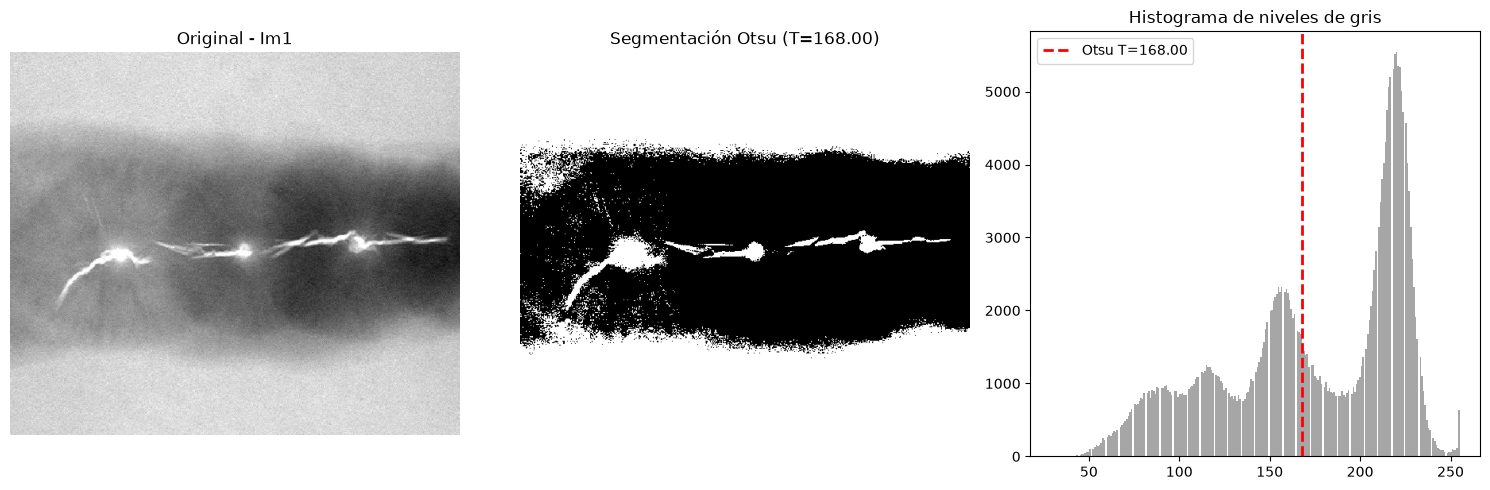

In [3]:
# 1. Leer la imagen y asegurarnos de que esté en escala de grises
img1 = io.imread('Im1.jpg', as_gray=True)

# 2. Calcular el umbral de Otsu y aplicar la máscara binaria
t_otsu = filters.threshold_otsu(img1)
mask_otsu = img1 > t_otsu

# 3. Visualizar la imagen original, la máscara de Otsu y el histograma
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Mostrar imagen original
axes[0].imshow(img1, cmap='gray')
axes[0].set_title('Original - Im1')
axes[0].axis('off')

# Mostrar segmentación de Otsu
axes[1].imshow(mask_otsu, cmap='gray')
axes[1].set_title(f'Segmentación Otsu (T={t_otsu:.2f})')
axes[1].axis('off')

# Mostrar el histograma
# img1.ravel() aplana la matriz 2D a 1D para calcular el histograma
axes[2].hist(img1.ravel(), bins=256, color='gray', alpha=0.7)
axes[2].axvline(t_otsu, color='r', linestyle='dashed', linewidth=2, label=f'Otsu T={t_otsu:.2f}')
axes[2].set_title('Histograma de niveles de gris')
axes[2].legend()

plt.tight_layout()
plt.show()

El programa detectó que un buen umbral seria en 168, otsu penso que habia que separar el fondo de la estructura, pero en realidad no buscamos eso. Un mejor umbral, teniendo en cuenta que queremos aislar solo los destellos mas brillantes, sería tomar solo lo ultimo del pico mas alto, cerca de 240. 

El filtro Gaussiano es un filtro "paso bajo". Las radiografías tienen un ruido granulado molesto (ruido de alta frecuencia). Si hacemos un zoom, veríamos puntitos blancos falsos Este filtro aplica una campana de Gauss sobre cada píxel. Básicamente, reemplaza el valor de cada píxel por un promedio ponderado de sus píxeles vecinos (los vecinos más cercanos importan más, los lejanos menos). Esto "difumina" la imagen suavemente, matando los puntitos de ruido rebeldes y unificando las manchas de los defectos reales.

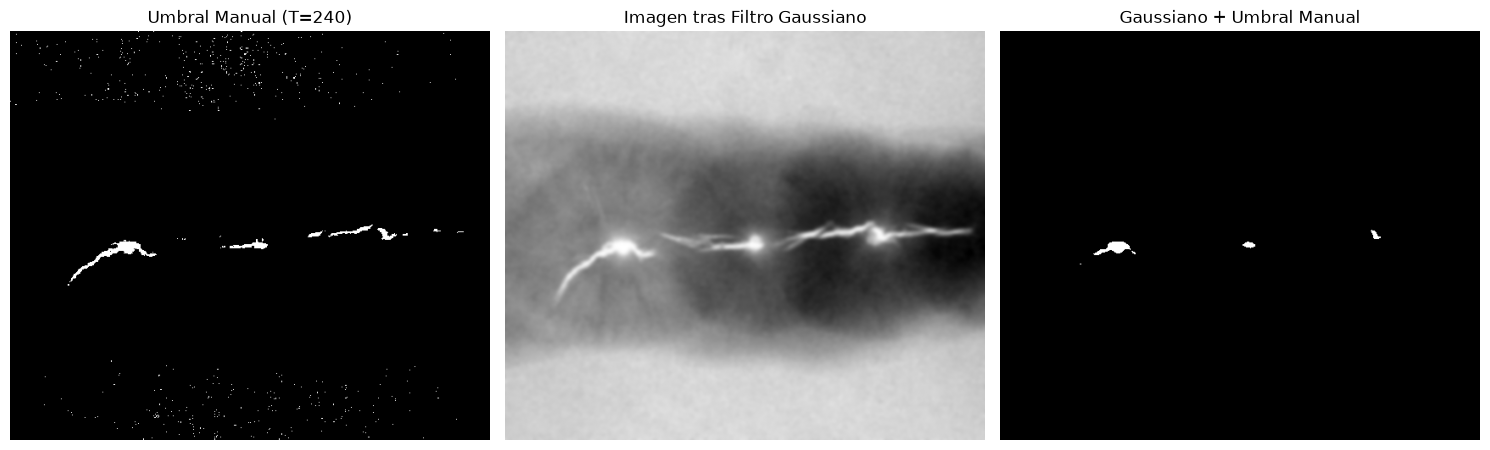

In [4]:
# --- 1. UMBRAL MANUAL ---
# Elegimos 240 para ignorar el fondo (pico de 220) y capturar solo el blanco brillante
t_manual = 240
mask_manual = img1 > t_manual

# --- 2. FILTRO GAUSSIANO + UMBRAL ---
# Aplicamos el filtro gaussiano. "sigma" controla el tamaño de la campana (qué tan borroso se hace).
img1_gaussian = filters.gaussian(img1, sigma=2)

# OJO: filters.gaussian convierte internamente la imagen a valores decimales entre 0.0 y 1.0
# Por lo tanto, nuestro umbral de 240 (escala de 255) debemos convertirlo a esa nueva escala matemática:
# T_nuevo = 240 / 255 = 0.941
t_gauss = 240 / 255.0
mask_gaussian = img1_gaussian > t_gauss

# --- 3. VISUALIZACIÓN ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Umbral Manual sin filtro
axes[0].imshow(mask_manual, cmap='gray')
axes[0].set_title(f'Umbral Manual (T={t_manual})')
axes[0].axis('off')

# Imagen difuminada con el filtro Gaussiano (solo para que veas qué hace el filtro)
axes[1].imshow(img1_gaussian, cmap='gray')
axes[1].set_title('Imagen tras Filtro Gaussiano')
axes[1].axis('off')

# Umbral Manual sobre la imagen con filtro Gaussiano
axes[2].imshow(mask_gaussian, cmap='gray')
axes[2].set_title('Gaussiano + Umbral Manual')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 1.2 GRAYLEVEL IMAGE CLUSTERING-BASED SEGMENTATION

¿Qué es K-Means?
Es un algoritmo de aprendizaje no supervisado. Toma todos los valores de intensidad de los píxeles (que van de 0 a 1 o de 0 a 255) y busca agruparlos alrededor de $K$ centros o centroides. Si indicamos $K=3$, el algoritmo buscará 3 niveles de gris representativos que dividan mejor toda la imagen en 3 categorías.

Formato de datos para scikit-learn:
Una imagen es una matriz 2D (alto $\times$ ancho, ej. $300 \times 300$). KMeans no entiende matrices 2D; necesita una lista vertical de datos de dimensión $(N, 1)$, donde $N$ es el número total de píxeles ($300 \times 300 = 90000$). Por eso usaremos reshape(-1, 1) antes de entrenar el modelo.

Análisis de Im2.jpg (3 centroides):
Agruparemos Im2.jpg en $K=3$ clases. Gráficamente, veremos el histograma junto con las posiciones de los 3 centroides encontrados.   Análisis de Im3.jpg (Anillo vs. Centro Denso vs. Fondo):

Im3.jpg es la imagen de una galaxia o nebulosa. Nos piden identificar 3 regiones:   

- El fondo oscuro.

- El "anillo" exterior de materia menos densa.

- La región central muy densa y brillante.

Uso de Filtros de Medios y Varianza Local:
A veces, agrupar píxel por píxel genera ruido. Para mejorarlo, la guía nos pide calcular:

- Media local (uniform_filter): Promedia una vecindad alrededor de cada píxel. Esto suaviza las variaciones bruscas de intensidad.   
- Varianza local (generic_filter con np.var): Mide qué tanto cambian los píxeles alrededor de una región. Las zonas de transición o con textura tendrán una varianza alta, mientras que las zonas uniformes tendrán una varianza baja. Al combinar la Media y la Varianza, cada píxel pasa de tener 1 característica (su brillo) a tener 2 características [Media_local, Varianza_local] para entrenar el K-Means en un espacio 2D.

In [ ]:
# --- PARTE A: Im2.jpg con K-Means (K=3) ---
img2 = io.imread('Im2.jpg', as_gray=True)

# Reorganizar la imagen de 2D a una columna 1D (N_pixeles, 1)
X2 = img2.reshape(-1, 1)

# Entrenar K-Means con 3 centroides
kmeans2 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X2)

# Obtener las etiquetas de cada píxel y reestructurar a la forma 2D original
segmented2 = kmeans2.labels_.reshape(img2.shape)
centroids2 = kmeans2.cluster_centers_

# Visualización de Im2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Imagen segmentada en pseudocolor
im2_plot = axes[0].imshow(segmented2, cmap='viridis')
axes[0].set_title('Im2 - Segmentación K-Means (3 clases)')
axes[0].axis('off')
plt.colorbar(im2_plot, ax=axes[0])

# Histograma con centroides
axes[1].hist(img2.ravel(), bins=256, color='gray', alpha=0.7)
for c in centroids2:
    axes[1].axvline(c[0], color='r', linestyle='--', linewidth=2)
axes[1].axvline(centroids2[0][0], color='r', linestyle='--', linewidth=2, label='Centroides K-Means')
axes[1].set_title('Im2 - Histograma y Centroides')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- PARTE B: Im3.jpg con K-Means básico (K=3) ---
img3 = io.imread('Im3.jpg', as_gray=True)

X3 = img3.reshape(-1, 1)
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X3)
segmented3 = kmeans3.labels_.reshape(img3.shape)
centroids3 = kmeans3.cluster_centers_

# Visualización de Im3 básica
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Imagen segmentada
im3_plot = axes[0].imshow(segmented3, cmap='viridis')
axes[0].set_title('Im3 - Segmentación K-Means Básica (3 clases)')
axes[0].axis('off')
plt.colorbar(im3_plot, ax=axes[0])

# Histograma con centroides
axes[1].hist(img3.ravel(), bins=256, color='gray', alpha=0.7)
for c in centroids3:
    axes[1].axvline(c[0], color='r', linestyle='--', linewidth=2)
axes[1].axvline(centroids3[0][0], color='r', linestyle='--', linewidth=2, label='Centroides K-Means')
axes[1].set_title('Im3 - Histograma y Centroides')
axes[1].legend()

plt.tight_layout()
plt.show()